
# Notebook sinh số liệu và hình ảnh cho báo cáo HOG + SVM / HOG + Random Forest

Notebook này dùng để:
1. Thống kê số lượng dữ liệu train / val / test.
2. Sinh bảng `data_counts.tex`.
3. Trực quan hóa pipeline tiền xử lý + HOG.
4. So sánh trực quan đặc trưng HOG với hai cấu hình **8x2** và **6x3**.
5. Tải 4 model đã huấn luyện trong thư mục `models`.
6. Đánh giá 4 model trên tập test.
7. Sinh bảng `model_comparison.tex` và các hình `model_comparison.png`, `confusion_matrix_best.png`.
8. Sinh ảnh pipeline dự đoán của mô hình tốt nhất.

> **Lưu ý:**
> - Hãy đặt notebook này trong project và chỉnh `BASE_DIR` nếu cần.
> - Sau khi chạy xong, các file phục vụ báo cáo sẽ nằm trong thư mục `report_assets`.


In [1]:
import os
import warnings
from pathlib import Path

import cv2
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from skimage.io import imread
from skimage.color import rgb2gray
from skimage.transform import resize
from skimage.feature import hog
from skimage import exposure

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    )

warnings.filterwarnings('ignore')

def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / 'data').exists() and (candidate / 'models').exists():
            return candidate
    return start

# =========================
# CAU HINH DUONG DAN
# =========================
# Neu muon tu chi dinh, mo comment dong duoi va set path.
# BASE_DIR = Path(r"E:\\Duong\\Dan\\Project")
BASE_DIR = find_project_root(Path.cwd())

DATA_DIR = BASE_DIR / 'data'
MODELS_DIR = BASE_DIR / 'models'
ASSETS_DIR = BASE_DIR / 'report_assets'
ASSETS_DIR.mkdir(parents=True, exist_ok=True)

CLASSES = ['Cam', 'Chidan', 'Hieulenh', 'Nguyhiem', 'Phu']
IMAGE_SIZE = (128, 128)
SEED = 42
VAL_SIZE = 0.2

model_files = {
    'HOG_SVM_6x3': MODELS_DIR / 'HOG_SVM_6x3.joblib',
    'HOG_SVM_8x2': MODELS_DIR / 'HOG_SVM_8x2.joblib',
    'HOG_RF_6x3': MODELS_DIR / 'HOG_RandomForest_6x3.joblib',
    'HOG_RF_8x2': MODELS_DIR / 'HOG_RandomForest_8x2.joblib',
}

print('BASE_DIR   :', BASE_DIR)
print('DATA_DIR   :', DATA_DIR)
print('MODELS_DIR :', MODELS_DIR)
print('ASSETS_DIR :', ASSETS_DIR)
print('\nKiem tra thu muc ton tai:')
print('- data  :', DATA_DIR.exists())
print('- models:', MODELS_DIR.exists())

if not DATA_DIR.exists() or not MODELS_DIR.exists():
    raise FileNotFoundError(
        "Khong tim thay thu muc 'data' hoac 'models'. "
        "Hay kiem tra lai BASE_DIR."
    )

BASE_DIR   : e:\CS-UIT\Ki 6\Nhập môn CV\CS231.Q22-TrafficSign-Classification
DATA_DIR   : e:\CS-UIT\Ki 6\Nhập môn CV\CS231.Q22-TrafficSign-Classification\data
MODELS_DIR : e:\CS-UIT\Ki 6\Nhập môn CV\CS231.Q22-TrafficSign-Classification\models
ASSETS_DIR : e:\CS-UIT\Ki 6\Nhập môn CV\CS231.Q22-TrafficSign-Classification\report_assets

Kiem tra thu muc ton tai:
- data  : True
- models: True


## 1. Các hàm hỗ trợ

In [2]:

def list_image_files(folder: Path):
    exts = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff', '.webp'}
    if not folder.exists():
        return []
    return sorted([p for p in folder.rglob('*') if p.suffix.lower() in exts])


def load_gray_resized(img_path: Path, image_size=IMAGE_SIZE):
    img = imread(img_path)
    if img.ndim == 3:
        if img.shape[2] == 4:
            img = img[:, :, :3]
        gray = rgb2gray(img)
    else:
        gray = img.astype(np.float32)
        if gray.max() > 1:
            gray = gray / 255.0

    resized = resize(gray, image_size, anti_aliasing=True)
    return img, gray, resized


def extract_hog_feature(gray_resized, hog_params):
    fd = hog(gray_resized, visualize=False, **hog_params)
    return fd


def enhance_hog_image(hog_image: np.ndarray) -> np.ndarray:
    image = np.asarray(hog_image, dtype=np.float32)
    image = np.nan_to_num(image, nan=0.0, posinf=0.0, neginf=0.0)
    image = np.maximum(image, 0.0)

    if float(image.max()) <= float(image.min()):
        return np.full((*image.shape, 3), 246, dtype=np.uint8)

    active = image[image > 0]
    if active.size == 0:
        return np.full((*image.shape, 3), 246, dtype=np.uint8)

    low = float(np.percentile(active, 5.0))
    high = float(np.percentile(active, 99.5))
    if high <= low:
        low = 0.0
        high = float(active.max())

    image = np.clip((image - low) / (high - low + 1e-8), 0.0, 1.0)
    image = np.power(image, 0.32)
    image_u8 = np.clip(image * 255.0, 0, 255).astype(np.uint8)
    image_u8 = cv2.dilate(image_u8, np.ones((2, 2), dtype=np.uint8), iterations=1)

    color_bgr = cv2.applyColorMap(image_u8, cv2.COLORMAP_TURBO)
    color_rgb = cv2.cvtColor(color_bgr, cv2.COLOR_BGR2RGB)
    canvas = np.full((*image_u8.shape, 3), 246, dtype=np.uint8)
    mask = image_u8 > 10
    alpha = (image_u8.astype(np.float32) / 255.0)[..., None]
    blended = canvas.astype(np.float32) * (1.0 - alpha) + color_rgb.astype(np.float32) * alpha
    canvas[mask] = blended[mask].astype(np.uint8)
    return canvas

def extract_hog_visual(gray_resized, hog_params):
    fd, hog_img = hog(gray_resized, visualize=True, **hog_params)
    hog_img = enhance_hog_image(hog_img)
    return fd, hog_img


def find_any_sample(class_name='Nguyhiem'):
    candidates = list_image_files(DATA_DIR / 'test' / class_name)
    if len(candidates) == 0:
        for cls in CLASSES:
            candidates = list_image_files(DATA_DIR / 'test' / cls)
            if len(candidates) > 0:
                break
    if len(candidates) == 0:
        raise FileNotFoundError('Không tìm thấy ảnh mẫu trong thư mục data/test.')
    return candidates[0]


def save_text(path: Path, text: str):
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, 'w', encoding='utf-8') as f:
        f.write(text)


def format_model_display_name(name: str):
    return name.replace('_', ' ')


hog_params_8x2 = {
    'orientations': 9,
    'pixels_per_cell': (8, 8),
    'cells_per_block': (2, 2),
    'block_norm': 'L2-Hys',
    'feature_vector': True,
}

hog_params_6x3 = {
    'orientations': 9,
    'pixels_per_cell': (6, 6),
    'cells_per_block': (3, 3),
    'block_norm': 'L2-Hys',
    'feature_vector': True,
}


## 2. Thống kê dữ liệu train / val / test

In [3]:
# Dem so luong anh trong tap train goc va test
train_full_counts = {}
test_counts = {}

all_train_paths = []
all_train_labels = []

for cls in CLASSES:
    train_cls_paths = list_image_files(DATA_DIR / 'train' / cls)
    test_cls_paths = list_image_files(DATA_DIR / 'test' / cls)

    train_full_counts[cls] = len(train_cls_paths)
    test_counts[cls] = len(test_cls_paths)

    all_train_paths.extend(train_cls_paths)
    all_train_labels.extend([cls] * len(train_cls_paths))

if len(all_train_paths) == 0:
    raise FileNotFoundError(
        f"Khong tim thay anh train trong {DATA_DIR / 'train'}. "
        "Hay kiem tra lai DATA_DIR/BASE_DIR."
    )

# Chia train / val tu train goc theo ti le 8/2, stratify, random_state=42
train_paths, val_paths, train_labels, val_labels = train_test_split(
    all_train_paths,
    all_train_labels,
    test_size=VAL_SIZE,
    random_state=SEED,
    stratify=all_train_labels,
    )

train_counts = {cls: 0 for cls in CLASSES}
val_counts = {cls: 0 for cls in CLASSES}

for y in train_labels:
    train_counts[y] += 1
for y in val_labels:
    val_counts[y] += 1

stats = []
for cls in CLASSES:
    stats.append({
        'Lớp': cls,
        'Train': train_counts[cls],
        'Validation': val_counts[cls],
        'Test': test_counts[cls],
        'Tổng': train_counts[cls] + val_counts[cls] + test_counts[cls],
    })

stats_df = pd.DataFrame(stats)
stats_df.loc[len(stats_df)] = {
    'Lớp': 'Tổng cộng',
    'Train': stats_df['Train'].sum(),
    'Validation': stats_df['Validation'].sum(),
    'Test': stats_df['Test'].sum(),
    'Tổng': stats_df['Tổng'].sum(),
}

print(stats_df)

# Xuat LaTeX table
latex_table = stats_df.to_latex(index=False, escape=False)
save_text(ASSETS_DIR / 'data_counts.tex', latex_table)
print(f'\nDa luu: {ASSETS_DIR / "data_counts.tex"}')

         Lớp  Train  Validation  Test  Tổng
0        Cam    490         123    68   681
1     Chidan    454         113    63   630
2   Hieulenh    470         117    65   652
3   Nguyhiem    473         118    66   657
4        Phu    297          75    41   413
5  Tổng cộng   2184         546   303  3033

Da luu: e:\CS-UIT\Ki 6\Nhập môn CV\CS231.Q22-TrafficSign-Classification\report_assets\data_counts.tex


## 3. Trực quan hóa HOG: pipeline đầy đủ và hình so sánh 8x2 vs 6x3

Ảnh mẫu sử dụng: e:\CS-UIT\Ki 6\Nhập môn CV\CS231.Q22-TrafficSign-Classification\data\test\Nguyhiem\Nguyhiem_001.jpg


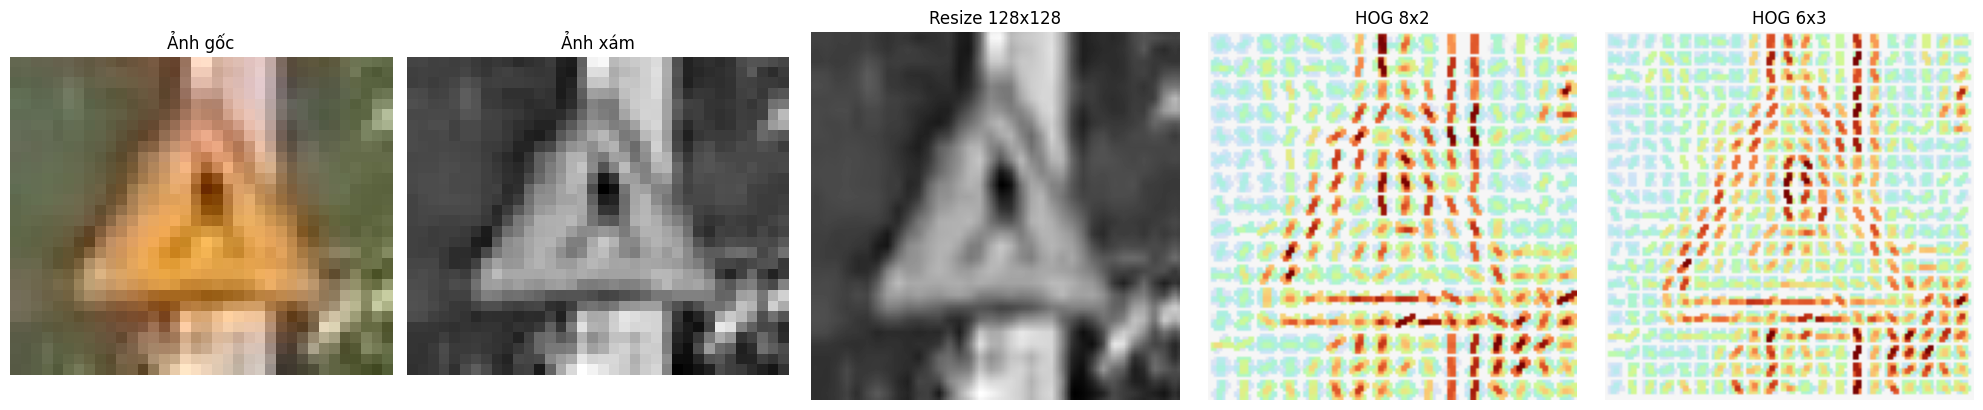

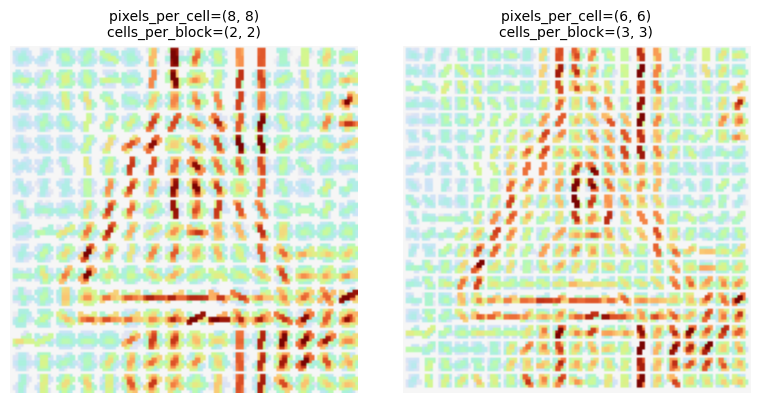

  Cấu hình HOG  orientations pixels_per_cell cells_per_block  \
0      HOG 8x2             9          (8, 8)          (2, 2)   
1      HOG 6x3             9          (6, 6)          (3, 3)   

   Số chiều đặc trưng  
0                8100  
1               29241  

Đã lưu: e:\CS-UIT\Ki 6\Nhập môn CV\CS231.Q22-TrafficSign-Classification\report_assets\prediction_pipeline_HOG_compare.png
Đã lưu: e:\CS-UIT\Ki 6\Nhập môn CV\CS231.Q22-TrafficSign-Classification\report_assets\hog_feature_compare.png
Đã lưu: e:\CS-UIT\Ki 6\Nhập môn CV\CS231.Q22-TrafficSign-Classification\report_assets\hog_feature_dimensions.tex


In [4]:

def visualize_hog_comparison(sample_path, save_path_pipeline, save_path_compare, save_path_dimensions):
    img, gray, resized = load_gray_resized(sample_path, IMAGE_SIZE)

    fd_8x2, hog_img_8x2 = extract_hog_visual(resized, hog_params_8x2)
    fd_6x3, hog_img_6x3 = extract_hog_visual(resized, hog_params_6x3)

    # ===== Hình 1: pipeline đầy đủ =====
    fig, axes = plt.subplots(1, 5, figsize=(20, 4))

    axes[0].imshow(img)
    axes[0].set_title('Ảnh gốc')

    axes[1].imshow(gray, cmap='gray')
    axes[1].set_title('Ảnh xám')

    axes[2].imshow(resized, cmap='gray')
    axes[2].set_title('Resize 128x128')

    axes[3].imshow(hog_img_8x2)
    axes[3].set_title('HOG 8x2')

    axes[4].imshow(hog_img_6x3)
    axes[4].set_title('HOG 6x3')

    for ax in axes:
        ax.axis('off')

    plt.tight_layout()
    plt.savefig(save_path_pipeline, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close(fig)

    # ===== Hình 2: chỉ so sánh 2 ảnh HOG =====
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))

    axes[0].imshow(hog_img_8x2)
    axes[0].set_title('pixels_per_cell=(8, 8)\ncells_per_block=(2, 2)', fontsize=10)
    axes[0].axis('off')

    axes[1].imshow(hog_img_6x3)
    axes[1].set_title('pixels_per_cell=(6, 6)\ncells_per_block=(3, 3)', fontsize=10)
    axes[1].axis('off')

    plt.tight_layout()
    plt.savefig(save_path_compare, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close(fig)

    # ===== Bảng số chiều vector đặc trưng =====
    dim_df = pd.DataFrame([
        {
            'Cấu hình HOG': 'HOG 8x2',
            'orientations': 9,
            'pixels_per_cell': '(8, 8)',
            'cells_per_block': '(2, 2)',
            'Số chiều đặc trưng': len(fd_8x2),
        },
        {
            'Cấu hình HOG': 'HOG 6x3',
            'orientations': 9,
            'pixels_per_cell': '(6, 6)',
            'cells_per_block': '(3, 3)',
            'Số chiều đặc trưng': len(fd_6x3),
        },
    ])

    print(dim_df)
    save_text(save_path_dimensions, dim_df.to_latex(index=False, escape=False))
    print(f'\nĐã lưu: {save_path_pipeline}')
    print(f'Đã lưu: {save_path_compare}')
    print(f'Đã lưu: {save_path_dimensions}')


sample_img = find_any_sample('Nguyhiem')
print('Ảnh mẫu sử dụng:', sample_img)

visualize_hog_comparison(
    sample_img,
    ASSETS_DIR / 'prediction_pipeline_HOG_compare.png',
    ASSETS_DIR / 'hog_feature_compare.png',
    ASSETS_DIR / 'hog_feature_dimensions.tex'
)


## 4. Đánh giá 4 model trên tập test

In [5]:
# Cell 4 - Danh gia 4 model da train tren tap test
# Cach viet nay tu doc cau hinh trong tung file .joblib de tranh sai pipeline feature.

def normalize_hog_params(params):
    params = dict(params or {})
    params.setdefault('orientations', 9)
    params.setdefault('block_norm', 'L2-Hys')
    params.setdefault('feature_vector', True)
    return params


def normalize_tuple(value, default_value):
    if value is None:
        return tuple(default_value)
    return tuple(value)


def to_uint8_rgb(image: np.ndarray) -> np.ndarray:
    if image.ndim == 2:
        image = np.stack([image, image, image], axis=-1)
    if image.ndim == 3 and image.shape[-1] == 4:
        image = image[..., :3]

    rgb = image.astype(np.float32)
    if rgb.max() <= 1.0:
        rgb *= 255.0
    return np.clip(rgb, 0, 255).astype(np.uint8)


def resize_rgb_image(image: np.ndarray, image_size) -> np.ndarray:
    height, width = tuple(image_size)
    rgb = to_uint8_rgb(image)
    return cv2.resize(rgb, (width, height), interpolation=cv2.INTER_AREA)


def extract_hsv_histogram(image: np.ndarray, image_size, hsv_bins) -> np.ndarray:
    rgb_resized = resize_rgb_image(image, image_size)
    hsv = cv2.cvtColor(rgb_resized, cv2.COLOR_RGB2HSV)
    h_bins, s_bins, v_bins = tuple(hsv_bins)

    hist_h = cv2.calcHist([hsv], [0], None, [h_bins], [0, 180]).flatten()
    hist_s = cv2.calcHist([hsv], [1], None, [s_bins], [0, 256]).flatten()
    hist_v = cv2.calcHist([hsv], [2], None, [v_bins], [0, 256]).flatten()

    feature = np.concatenate([hist_h, hist_s, hist_v]).astype(np.float32)
    feature /= feature.sum() + 1e-8
    return feature


def build_feature_from_path(img_path: Path, hog_params, image_size, hsv_bins=None) -> np.ndarray:
    image, _, gray_resized = load_gray_resized(img_path, image_size)
    hog_feature = hog(gray_resized, **normalize_hog_params(hog_params)).astype(np.float32)

    if hsv_bins is None:
        return hog_feature

    color_feature = extract_hsv_histogram(image, image_size, hsv_bins)
    return np.concatenate([hog_feature, color_feature])


def get_model_parts(model_name: str, model_path: Path):
    payload = joblib.load(model_path)

    if isinstance(payload, dict):
        model = payload.get('model')
        label_encoder = payload.get('label_encoder')
        hog_params = payload.get('hog_params')
        hsv_bins = payload.get('hsv_hist_bins')
        image_size = payload.get('image_size', IMAGE_SIZE)
        classes = payload.get('classes')
    else:
        model = payload
        label_encoder = None
        hog_params = hog_params_6x3 if '6x3' in model_name else hog_params_8x2
        hsv_bins = None
        image_size = IMAGE_SIZE
        classes = CLASSES

    if model is None:
        raise ValueError('Payload khong co key model.')

    # RandomForest luu voi n_jobs > 1 co the gay WinError 5 trong mot so kernel Windows.
    # Ep ve 1 khi evaluate de predict on dinh hon, khong lam thay doi file model tren dia.
    if hasattr(model, 'n_jobs'):
        model.n_jobs = 1

    hog_params = normalize_hog_params(hog_params_6x3 if hog_params is None and '6x3' in model_name else hog_params)
    hog_params = normalize_hog_params(hog_params_8x2 if hog_params is None and '8x2' in model_name else hog_params)
    image_size = normalize_tuple(image_size, IMAGE_SIZE)
    hsv_bins = None if hsv_bins is None else normalize_tuple(hsv_bins, (16, 8, 8))

    if classes is None and label_encoder is not None:
        classes = list(label_encoder.classes_)
    if classes is None:
        classes = CLASSES

    return payload, model, label_encoder, hog_params, hsv_bins, image_size, [str(c) for c in classes]


def collect_test_samples() -> list[tuple[Path, str]]:
    samples = []
    for cls in CLASSES:
        for img_path in list_image_files(DATA_DIR / 'test' / cls):
            samples.append((img_path, cls))
    return samples


def evaluate_one_model(model_name: str, model_path: Path, test_samples):
    if not model_path.exists():
        raise FileNotFoundError(f'Khong tim thay file model: {model_path}')

    payload, model, label_encoder, hog_params, hsv_bins, image_size, class_names = get_model_parts(model_name, model_path)

    features = []
    labels_text = []
    skipped = []

    for img_path, label in test_samples:
        try:
            features.append(build_feature_from_path(img_path, hog_params, image_size, hsv_bins))
            labels_text.append(label)
        except Exception as exc:
            skipped.append((img_path, str(exc)))

    if not features:
        raise RuntimeError('Khong extract duoc feature nao tu tap test.')

    X_test_model = np.vstack(features)
    expected_dim = getattr(model, 'n_features_in_', None)
    if expected_dim is not None and X_test_model.shape[1] != expected_dim:
        raise ValueError(
            f'Sai so chieu feature: tao duoc {X_test_model.shape[1]}, '
            f'nhung model can {expected_dim}. Hay kiem tra HOG/HSV params.'
        )

    if label_encoder is not None:
        known_labels = set(label_encoder.classes_)
        keep_idx = [i for i, label in enumerate(labels_text) if label in known_labels]
        if len(keep_idx) != len(labels_text):
            dropped = len(labels_text) - len(keep_idx)
            print(f'{model_name}: bo qua {dropped} anh co label khong nam trong label_encoder.')
        X_test_model = X_test_model[keep_idx]
        labels_text = [labels_text[i] for i in keep_idx]
        y_true = label_encoder.transform(labels_text)
        report_labels = np.arange(len(label_encoder.classes_))
        class_names = [str(c) for c in label_encoder.classes_]
    else:
        y_true = np.array(labels_text)
        report_labels = class_names

    y_pred = model.predict(X_test_model)

    acc = accuracy_score(y_true, y_pred)
    weighted_f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    macro_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)

    report_text = classification_report(
        y_true,
        y_pred,
        labels=report_labels,
        target_names=class_names,
        digits=4,
        zero_division=0,
    )

    return {
        'name': model_name,
        'model': model,
        'label_encoder': label_encoder,
        'hog_params': hog_params,
        'hsv_bins': hsv_bins,
        'image_size': image_size,
        'class_names': class_names,
        'y_true': y_true,
        'y_pred': y_pred,
        'test_labels_text': labels_text,
        'accuracy': acc,
        'weighted_f1': weighted_f1,
        'macro_f1': macro_f1,
        'report_text': report_text,
        'n_samples': len(labels_text),
        'n_skipped': len(skipped),
        'skipped': skipped,
    }


test_samples = collect_test_samples()
if not test_samples:
    raise FileNotFoundError(f'Khong tim thay anh test trong {DATA_DIR / "test"}')

print(f'So anh test tim thay: {len(test_samples)}')
print(pd.Series([label for _, label in test_samples]).value_counts().sort_index().to_string())

results = []
classification_reports = {}
model_eval_details = {}
failed_models = {}
best_model_data = None
best_acc = -np.inf

for model_name, model_path in model_files.items():
    print('\n' + '=' * 72)
    print(f'Danh gia model: {model_name}')

    try:
        info = evaluate_one_model(model_name, model_path, test_samples)
    except Exception as exc:
        failed_models[model_name] = str(exc)
        print(f'Loi khi danh gia {model_name}: {exc}')
        continue

    classification_reports[model_name] = info['report_text']
    model_eval_details[model_name] = info

    print(info['report_text'])
    if info['n_skipped']:
        print(f'Bo qua {info["n_skipped"]} anh loi. Mot vai file dau:')
        for bad_path, reason in info['skipped'][:5]:
            print(f'- {bad_path.name}: {reason}')

    save_text(ASSETS_DIR / f'classification_report_{model_name}.txt', info['report_text'])

    results.append({
        'M\u00f4 h\u00ecnh': format_model_display_name(model_name),
        'Accuracy': round(info['accuracy'], 4),
        'F1-Score': round(info['weighted_f1'], 4),
        'Macro F1': round(info['macro_f1'], 4),
        'Samples': info['n_samples'],
        'Skipped': info['n_skipped'],
    })

    if info['accuracy'] > best_acc:
        best_acc = info['accuracy']
        best_model_data = info

results_df = pd.DataFrame(results)
if not results_df.empty:
    results_df = results_df.sort_values(['Accuracy', 'F1-Score'], ascending=False).reset_index(drop=True)
else:
    results_df = pd.DataFrame(columns=['M\u00f4 h\u00ecnh', 'Accuracy', 'F1-Score', 'Macro F1', 'Samples', 'Skipped'])

print('\nBang tong hop ket qua:')
try:
    display(results_df)
except NameError:
    print(results_df.to_string(index=False))

save_text(ASSETS_DIR / 'model_comparison.tex', results_df.to_latex(index=False, escape=False))
print(f'Da luu bang LaTeX: {ASSETS_DIR / "model_comparison.tex"}')

if failed_models:
    print('\nCac model bi loi:')
    for name, reason in failed_models.items():
        print(f'- {name}: {reason}')

if best_model_data is not None:
    print(f'\nModel tot nhat: {best_model_data["name"]} | Accuracy = {best_acc:.4f}')


So anh test tim thay: 303
Cam         68
Chidan      63
Hieulenh    65
Nguyhiem    66
Phu         41

Danh gia model: HOG_SVM_6x3
              precision    recall  f1-score   support

         Cam     0.9559    0.9559    0.9559        68
      Chidan     0.8333    0.8730    0.8527        63
    Hieulenh     0.9000    0.8308    0.8640        65
    Nguyhiem     0.9851    1.0000    0.9925        66
         Phu     0.7857    0.8049    0.7952        41

    accuracy                         0.9010       303
   macro avg     0.8920    0.8929    0.8921       303
weighted avg     0.9017    0.9010    0.9009       303


Danh gia model: HOG_SVM_8x2
              precision    recall  f1-score   support

         Cam     0.9706    0.9706    0.9706        68
      Chidan     0.8028    0.9048    0.8507        63
    Hieulenh     0.9167    0.8462    0.8800        65
    Nguyhiem     0.9851    1.0000    0.9925        66
         Phu     0.8919    0.8049    0.8462        41

    accuracy              

,Mô hình,Accuracy,F1-Score,Macro F1,Samples,Skipped
0,HOG SVM 8x2,0.9142,0.9142,0.9080,303,0
1,HOG RF 8x2,0.9109,0.9106,0.9059,303,0
2,HOG SVM 6x3,0.9010,0.9009,0.8921,303,0
3,HOG RF 6x3,0.8878,0.8875,0.8821,303,0


Da luu bang LaTeX: e:\CS-UIT\Ki 6\Nhập môn CV\CS231.Q22-TrafficSign-Classification\report_assets\model_comparison.tex

Model tot nhat: HOG_SVM_8x2 | Accuracy = 0.9142


## 5. Vẽ biểu đồ so sánh và confusion matrix của mô hình tốt nhất

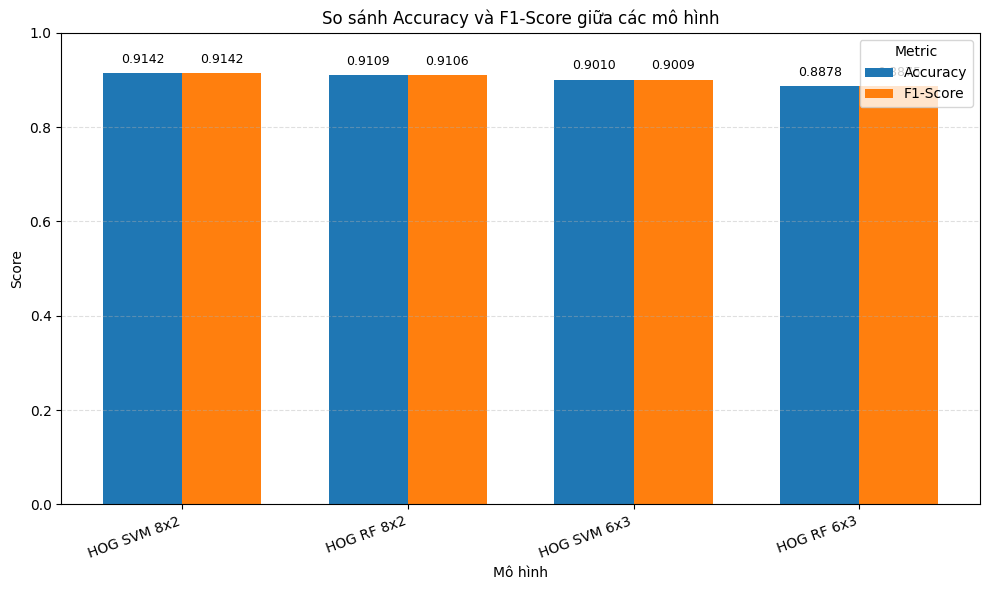

Đã lưu: e:\CS-UIT\Ki 6\Nhập môn CV\CS231.Q22-TrafficSign-Classification\report_assets\model_comparison.png


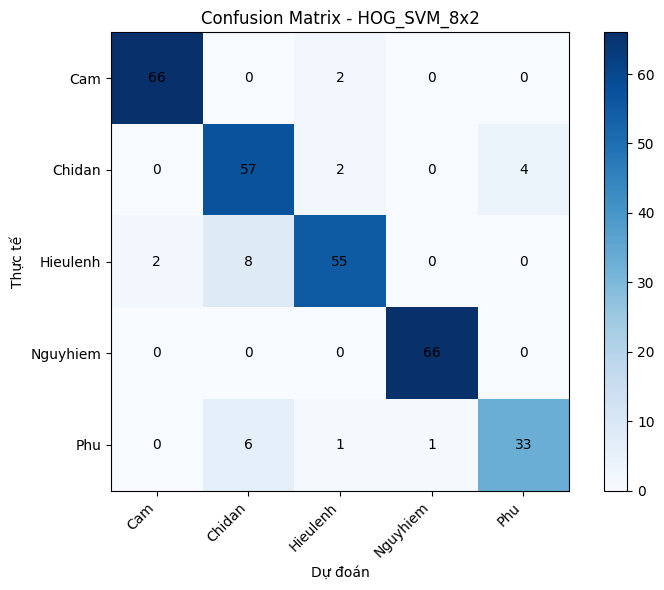

Đã lưu: e:\CS-UIT\Ki 6\Nhập môn CV\CS231.Q22-TrafficSign-Classification\report_assets\confusion_matrix_best.png
Mô hình tốt nhất hiện tại: HOG_SVM_8x2 | Accuracy = 0.9142


In [6]:
# ===== Biểu đồ cột so sánh =====
if len(results_df) > 0:
    x = np.arange(len(results_df))
    width = 0.35

    fig, ax = plt.subplots(figsize=(10, 6))

    bars_acc = ax.bar(
        x - width / 2,
        results_df['Accuracy'],
        width=width,
        label='Accuracy'
    )

    bars_f1 = ax.bar(
        x + width / 2,
        results_df['F1-Score'],
        width=width,
        label='F1-Score'
    )

    ax.set_xticks(x)
    ax.set_xticklabels(results_df['Mô hình'], rotation=20, ha='right')

    # Sửa lỗi biểu đồ bị trống:
    # Không đặt ylim từ 0.8 vì các score hiện tại có mô hình thấp hơn 0.8.
    # Đặt từ 0 đến 1 để phù hợp với thang đo Accuracy/F1-score.
    ax.set_ylim(0, 1.0)

    ax.set_ylabel('Score')
    ax.set_xlabel('Mô hình')
    ax.set_title('So sánh Accuracy và F1-Score giữa các mô hình')
    ax.legend(title='Metric')
    ax.grid(axis='y', linestyle='--', alpha=0.4)

    # Hiển thị giá trị trên đầu từng cột
    for bars in [bars_acc, bars_f1]:
        for bar in bars:
            height = bar.get_height()
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                height + 0.015,
                f'{height:.4f}',
                ha='center',
                va='bottom',
                fontsize=9
            )

    plt.tight_layout()
    plt.savefig(ASSETS_DIR / 'model_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close(fig)

    print(f'Đã lưu: {ASSETS_DIR / "model_comparison.png"}')
else:
    print('Không có kết quả mô hình để vẽ biểu đồ.')


# ===== Confusion matrix cho mô hình tốt nhất =====
if best_model_data is not None:
    cm = confusion_matrix(best_model_data['y_true'], best_model_data['y_pred'])
    class_names = best_model_data['class_names']

    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(cm, cmap='Blues')
    plt.colorbar(im, ax=ax)

    ax.set_xticks(np.arange(len(class_names)))
    ax.set_yticks(np.arange(len(class_names)))
    ax.set_xticklabels(class_names, rotation=45, ha='right')
    ax.set_yticklabels(class_names)
    ax.set_xlabel('Dự đoán')
    ax.set_ylabel('Thực tế')
    ax.set_title(f'Confusion Matrix - {best_model_data["name"]}')

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha='center', va='center', color='black')

    plt.tight_layout()
    plt.savefig(ASSETS_DIR / 'confusion_matrix_best.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close(fig)

    print(f'Đã lưu: {ASSETS_DIR / "confusion_matrix_best.png"}')
    print(f'Mô hình tốt nhất hiện tại: {best_model_data["name"]} | Accuracy = {best_acc:.4f}')
else:
    print('Chưa có mô hình tốt nhất để vẽ confusion matrix.')



## 6. Sinh ảnh pipeline dự đoán cho mô hình tốt nhất

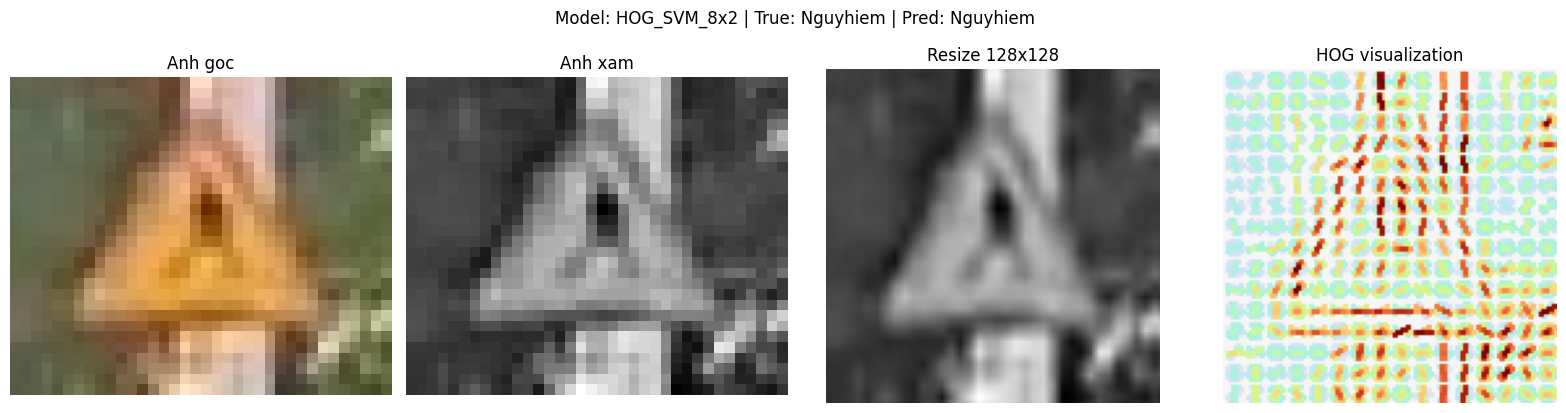

Da luu: e:\CS-UIT\Ki 6\Nhập môn CV\CS231.Q22-TrafficSign-Classification\report_assets\prediction_pipeline_HOG_SVM_8x2.png
Da luu: e:\CS-UIT\Ki 6\Nhập môn CV\CS231.Q22-TrafficSign-Classification\report_assets\prediction_pipeline_best.png


In [7]:
def create_prediction_pipeline_for_best(best_model_data, save_dir: Path):
    if best_model_data is None:
        print('Khong co best_model_data.')
        return

    best_name = best_model_data['name']
    best_model = best_model_data['model']
    best_le = best_model_data['label_encoder']
    best_hog_params = best_model_data['hog_params']
    best_hsv_bins = best_model_data.get('hsv_bins')
    best_image_size = best_model_data.get('image_size', IMAGE_SIZE)

    sample_path = find_any_sample('Nguyhiem')
    img, gray, resized = load_gray_resized(sample_path, best_image_size)

    _, hog_img = extract_hog_visual(resized, best_hog_params)
    feat = build_feature_from_path(sample_path, best_hog_params, best_image_size, best_hsv_bins).reshape(1, -1)
    pred_idx = best_model.predict(feat)[0]

    if best_le is not None:
        pred_label = best_le.inverse_transform([pred_idx])[0]
    else:
        pred_label = CLASSES[int(pred_idx)] if isinstance(pred_idx, (int, np.integer)) else str(pred_idx)

    true_label = sample_path.parent.name

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    axes[0].imshow(img, cmap='gray' if img.ndim == 2 else None)
    axes[0].set_title('Anh goc')
    axes[1].imshow(gray, cmap='gray')
    axes[1].set_title('Anh xam')
    axes[2].imshow(resized, cmap='gray')
    axes[2].set_title(f'Resize {best_image_size[0]}x{best_image_size[1]}')
    axes[3].imshow(hog_img)
    axes[3].set_title('HOG visualization')

    for ax in axes:
        ax.axis('off')

    fig.suptitle(
        f'Model: {best_name} | True: {true_label} | Pred: {pred_label}',
        fontsize=12,
        y=1.02,
    )

    plt.tight_layout()
    specific_path = save_dir / f'prediction_pipeline_{best_name}.png'
    generic_path = save_dir / 'prediction_pipeline_best.png'
    plt.savefig(specific_path, dpi=300, bbox_inches='tight')
    plt.savefig(generic_path, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close(fig)

    print(f'Da luu: {specific_path}')
    print(f'Da luu: {generic_path}')


create_prediction_pipeline_for_best(best_model_data, ASSETS_DIR)


## 7. Tóm tắt nhanh các file đã sinh

In [8]:

files = sorted([p.name for p in ASSETS_DIR.glob('*')])
print('Các file hiện có trong report_assets:')
for f in files:
    print('-', f)


Các file hiện có trong report_assets:
- classification_report_HOG_RF_6x3.txt
- classification_report_HOG_RF_8x2.txt
- classification_report_HOG_SVM_6x3.txt
- classification_report_HOG_SVM_8x2.txt
- confusion_matrix_best.png
- data_counts.tex
- hog_feature_compare.png
- hog_feature_dimensions.tex
- model_comparison.png
- model_comparison.tex
- prediction_pipeline_HOG_SVM_6x3.png
- prediction_pipeline_HOG_SVM_8x2.png
- prediction_pipeline_HOG_compare.png
- prediction_pipeline_best.png
